In [1]:
import os
original_path = 'C:\\Users\\dhars\\Desktop\\BTS\\'

In [2]:
for member in os.listdir(original_path):
    member_path = os.path.join(original_path, member)
    if os.path.isdir(member_path):
        print(f"Contents of '{member}':")
        for file in os.listdir(member_path):
            print(file)
    print("\n")

Contents of 'J Hope':
Snapinsta.app_117292040_751935052224406_22071758414935328_n_1080.jpg
Snapinsta.app_117817787_334784221218511_3788843743462703289_n_1080.jpg
Snapinsta.app_121035072_283440865957646_7981185704241449039_n_1080.jpg
Snapinsta.app_123658981_856861958382508_2333833865310086567_n_1080.jpg
Snapinsta.app_123944270_726275278244344_3763767694913224824_n_1080.jpg
Snapinsta.app_16228673_258932811202136_7481639386736492544_n_1080.jpg
Snapinsta.app_16230204_246836139077350_8876873054873976832_n_1080.jpg
Snapinsta.app_16230968_1828935010698995_3472653136680714240_n_1080.jpg
Snapinsta.app_16464493_1984178231809602_5930687298415886336_n_1080.jpg
Snapinsta.app_185063159_179161287424182_2622065734731342500_n_1080.jpg
Snapinsta.app_187287091_538893027119272_374124068257073455_n_1080.jpg
Snapinsta.app_190476570_228444872024717_3680237872661395811_n_1080.jpg
Snapinsta.app_192738251_103570081868528_1816570125991286139_n_1080.jpg
Snapinsta.app_195179037_214163720536663_3195491445090058793_

In [3]:
import os
from PIL import Image
directory_path = "C:\\Users\\dhars\\Desktop\\BTS_0\\"

In [4]:
def generate_annotation(image_width, image_height):
    """
    Generate a simple annotation with a bounding box covering a significant part of the image.
    The bounding box is assumed to be centered and covering most of the image area.
    """
    bbox_width = 0.8 * image_width
    bbox_height = 0.8 * image_height
    x_center = image_width / 2
    y_center = image_height / 2
    
    norm_x_center = x_center / image_width
    norm_y_center = y_center / image_height
    norm_bbox_width = bbox_width / image_width
    norm_bbox_height = bbox_height / image_height
    return f"0 {norm_x_center} {norm_y_center} {norm_bbox_width} {norm_bbox_height}"

In [5]:
for member in os.listdir(directory_path):
    member_path = os.path.join(directory_path, member)
    if os.path.isdir(member_path):
        for image_file in os.listdir(member_path):
            if image_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_path = os.path.join(member_path, image_file)
                with Image.open(image_path) as img:
                    width, height = img.size
                annotation = generate_annotation(width, height)
                annotation_file_path = os.path.splitext(image_path)[0] + '.txt'
                with open(annotation_file_path, 'w') as f:
                    f.write(annotation)

print("Annotation files generated.")

Annotation files generated.


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

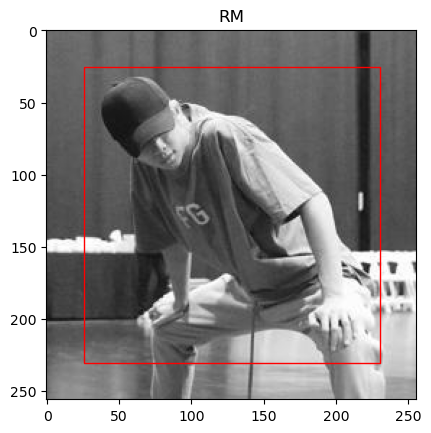

In [7]:
def display_image_with_annotations(image_path, annotation_path, member_name):
    """
    Display an image with its bounding box annotations and a caption.
    """
    # Load the image
    img = Image.open(image_path)
    fig, ax = plt.subplots(1)
    ax.imshow(img)
    
    # Read the annotation for the bounding box
    with open(annotation_path, 'r') as file:
        annotation = file.readline()
        _, x_center, y_center, width, height = map(float, annotation.split())
        
        # Convert normalized coordinates to pixel coordinates for matplotlib
        img_width, img_height = img.size
        box_width = width * img_width
        box_height = height * img_height
        bottom_left_x = (x_center * img_width) - (box_width / 2)
        bottom_left_y = (y_center * img_height) - (box_height / 2)
        
        # Create a Rectangle patch
        rect = patches.Rectangle((bottom_left_x, bottom_left_y), box_width, box_height, linewidth=1, edgecolor='r', facecolor='none')
        
        # Add the patch to the Axes
        ax.add_patch(rect)
    
    # Add caption with the member's name
    plt.title(f"{member_name}")
    plt.show()

# Randomly select a member directory
members = [member for member in os.listdir(directory_path) if os.path.isdir(os.path.join(directory_path, member))]
random_member = random.choice(members)
member_path = os.path.join(directory_path, random_member)

# Randomly select an image file from the selected member's directory
image_files = [file for file in os.listdir(member_path) if file.lower().endswith(('.png', '.jpg', '.jpeg'))]
random_image_file = random.choice(image_files)
image_path = os.path.join(member_path, random_image_file)
annotation_path = os.path.splitext(image_path)[0] + '.txt'

# Display the randomly selected image with annotations
display_image_with_annotations(image_path, annotation_path, random_member)


In [8]:
desired_size = (256, 256) 

In [9]:
for member in os.listdir(directory_path):
    member_path = os.path.join(directory_path, member)
    if os.path.isdir(member_path):
        for file in os.listdir(member_path):
            file_path = os.path.join(member_path, file)
            try:
                with Image.open(file_path) as img:
                    img = img.resize(desired_size)
                    img.save(file_path)
            except Exception as e:
                print(f"Error processing {file_path}: {e}")

Error processing C:\Users\dhars\Desktop\BTS_0\J Hope\Snapinsta.app_117292040_751935052224406_22071758414935328_n_1080.txt: cannot identify image file 'C:\\Users\\dhars\\Desktop\\BTS_0\\J Hope\\Snapinsta.app_117292040_751935052224406_22071758414935328_n_1080.txt'
Error processing C:\Users\dhars\Desktop\BTS_0\J Hope\Snapinsta.app_117817787_334784221218511_3788843743462703289_n_1080.txt: cannot identify image file 'C:\\Users\\dhars\\Desktop\\BTS_0\\J Hope\\Snapinsta.app_117817787_334784221218511_3788843743462703289_n_1080.txt'
Error processing C:\Users\dhars\Desktop\BTS_0\J Hope\Snapinsta.app_121035072_283440865957646_7981185704241449039_n_1080.txt: cannot identify image file 'C:\\Users\\dhars\\Desktop\\BTS_0\\J Hope\\Snapinsta.app_121035072_283440865957646_7981185704241449039_n_1080.txt'
Error processing C:\Users\dhars\Desktop\BTS_0\J Hope\Snapinsta.app_123658981_856861958382508_2333833865310086567_n_1080.txt: cannot identify image file 'C:\\Users\\dhars\\Desktop\\BTS_0\\J Hope\\Snapinst

In [10]:
for member in os.listdir(directory_path):
    member_path = os.path.join(directory_path, member)
    if os.path.isdir(member_path):
        for file in os.listdir(member_path):
            file_path = os.path.join(member_path, file)
            try:
                with Image.open(file_path) as img:
                    img_flipped = img.transpose(Image.FLIP_LEFT_RIGHT)
                    img_flipped.save(os.path.splitext(file_path)[0] + '_flipped.jpg')
            except Exception as e:
                print(f"Error processing {file_path}: {e}")

Error processing C:\Users\dhars\Desktop\BTS_0\J Hope\Snapinsta.app_117292040_751935052224406_22071758414935328_n_1080.txt: cannot identify image file 'C:\\Users\\dhars\\Desktop\\BTS_0\\J Hope\\Snapinsta.app_117292040_751935052224406_22071758414935328_n_1080.txt'
Error processing C:\Users\dhars\Desktop\BTS_0\J Hope\Snapinsta.app_117817787_334784221218511_3788843743462703289_n_1080.txt: cannot identify image file 'C:\\Users\\dhars\\Desktop\\BTS_0\\J Hope\\Snapinsta.app_117817787_334784221218511_3788843743462703289_n_1080.txt'
Error processing C:\Users\dhars\Desktop\BTS_0\J Hope\Snapinsta.app_121035072_283440865957646_7981185704241449039_n_1080.txt: cannot identify image file 'C:\\Users\\dhars\\Desktop\\BTS_0\\J Hope\\Snapinsta.app_121035072_283440865957646_7981185704241449039_n_1080.txt'
Error processing C:\Users\dhars\Desktop\BTS_0\J Hope\Snapinsta.app_123658981_856861958382508_2333833865310086567_n_1080.txt: cannot identify image file 'C:\\Users\\dhars\\Desktop\\BTS_0\\J Hope\\Snapinst

In [11]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import os
import random

In [12]:
def display_images(images, titles, cols=3):
    rows = len(images) // cols + (1 if len(images) % cols else 0)
    plt.figure(figsize=(cols * 4, rows * 4))
    for i, image in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(image)
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [13]:
def augment_image(image):
    flipped = ImageOps.mirror(image)
    rotated = image.rotate(15)
    return [image, flipped, rotated]

In [14]:
member = random.choice(os.listdir(directory_path)) 
member_path = os.path.join(directory_path, member)
image_name = random.choice(os.listdir(member_path)) 
image_path = os.path.join(member_path, image_name)

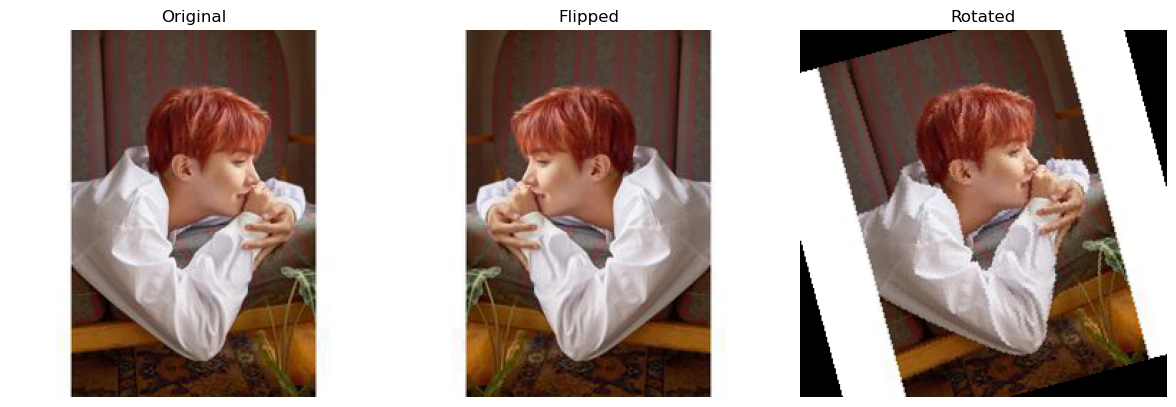

In [15]:
image = Image.open(image_path)
augmented_images = augment_image(image)
titles = ['Original', 'Flipped', 'Rotated']
display_images(augmented_images, titles)

In [16]:
rotation_degrees = [15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210, 225, 240, 255, 270, 285, 300, 315, 330, 345]
for member in os.listdir(directory_path):
    member_path = os.path.join(directory_path, member)
    if os.path.isdir(member_path):
        for file_name in os.listdir(member_path):
            file_path = os.path.join(member_path, file_name)
            if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                try:
                    with Image.open(file_path) as img:
                        for degrees in rotation_degrees:
                            img = img.resize(desired_size)
                            img_rotated = img.rotate(degrees, expand=True)
                            img_rotated.save(os.path.splitext(file_path)[0] + f'_rotated_{degrees}.jpg')
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

In [17]:
import os
import shutil
from sklearn.model_selection import train_test_split

In [18]:
directory_path = "C:\\Users\\dhars\\Desktop\\BTS_0\\"
train_dir = "C:\\Users\\dhars\\Desktop\\BTS_1\\Training Data"
test_dir = "C:\\Users\\dhars\\Desktop\\BTS_1\\Testing Data"

In [19]:
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

In [20]:
def process_and_split_member_images(member):
    member_path = os.path.join(directory_path, member)
    images = [os.path.join(member_path, f) for f in os.listdir(member_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    train_images, test_images = train_test_split(images, test_size=0.2, random_state=42)
    
    def copy_images(image_paths, destination):
        os.makedirs(destination, exist_ok=True)
        for path in image_paths:
            shutil.copy(path, destination)

    member_train_dir = os.path.join(train_dir, member)
    member_test_dir = os.path.join(test_dir, member)
    copy_images(train_images, member_train_dir)
    copy_images(test_images, member_test_dir)

In [21]:
for member in os.listdir(directory_path):
    if os.path.isdir(os.path.join(directory_path, member)):
        process_and_split_member_images(member)

print("Completed processing and splitting images for all members.")

Completed processing and splitting images for all members.


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

In [23]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255)

In [24]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical')

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical')

Found 13440 images belonging to 7 classes.
Found 3360 images belonging to 7 classes.


In [25]:
def create_cnn_model(input_shape, num_classes):
    model = Sequential([
        Conv2D(16, kernel_size=(3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    return model

In [26]:
num_classes = 7
model = create_cnn_model((64, 64, 3), num_classes)

In [27]:
early_stopping = EarlyStopping(
    monitor='val_loss',     
    patience=5,             
    verbose=1,              
    restore_best_weights=True  
)

In [28]:
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

In [29]:
epochs = 70
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=test_generator,
    callbacks=[early_stopping])

Epoch 1/70


420/420 [==============================] - 191s 452ms/step - loss: 1.9473 - accuracy: 0.1418 - val_loss: 1.9455 - val_accuracy: 0.1524
Epoch 2/70
420/420 [==============================] - 67s 159ms/step - loss: 1.9463 - accuracy: 0.1490 - val_loss: 1.9462 - val_accuracy: 0.1402
Epoch 3/70
420/420 [==============================] - 64s 152ms/step - loss: 1.9459 - accuracy: 0.1459 - val_loss: 1.9464 - val_accuracy: 0.1455
Epoch 4/70
420/420 [==============================] - 61s 146ms/step - loss: 1.9443 - accuracy: 0.1526 - val_loss: 1.9394 - val_accuracy: 0.1777
Epoch 5/70
420/420 [==============================] - 67s 159ms/step - loss: 1.9407 - accuracy: 0.1631 - val_loss: 1.9299 - val_accuracy: 0.1896
Epoch 6/70
420/420 [==============================] - 67s 159ms/step - loss: 1.9328 - accuracy: 0.1763 - val_loss: 1.9172 - val_accuracy: 0.1851
Epoch 7/70
420/420 [==============================] - 66s 158ms/step - loss: 1.9193 - accuracy: 0.1827 - val_loss: 1.9007 - val

In [30]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

105/105 [==============================] - 7s 70ms/step - loss: 0.7734 - accuracy: 0.7193
Test Loss: 0.7733513116836548
Test Accuracy: 0.719345211982727


In [31]:
model.save(r"C:\\Users\\dhars\\Desktop\\bts_member_recognition_model.h5")

C:\Users\dhars\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
